#  Chest X-Ray Pneumonia Detection
### Transfer Learning with ResNet18 | Google Drive Dataset

---

| | |
|---|---|
| **Dataset** | Chest X-Ray (Pneumonia) — from your Google Drive |
| **Model** | ResNet18 pretrained on ImageNet |
| **Task** | Binary Classification: NORMAL vs PNEUMONIA |
| **Output** | Trained model saved as `.pkl` (pickle) |

>  **Runtime:** `Runtime → Change runtime type → T4 GPU` before running.

---

##  Sections
1. [Install & Import Libraries](#section1)
2. [Mount Google Drive & Set Paths](#section2)
3. [Copy Dataset to Local SSD + Fix Val Set](#section3)
4. [Explore & Visualize Dataset](#section4)
5. [Data Preprocessing & Augmentation](#section5)
6. [Build Model (ResNet18)](#section6)
7. [Train with Early Stopping](#section7)
8. [Evaluate Model](#section8)
9. [Save as Pickle & Download](#section9)

<a id='section1'></a>
##  Section 1 — Install & Import Libraries

In [ ]:
!pip install torchinfo --quiet

In [ ]:
import os, json, pickle, shutil, random, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import datasets, transforms, models
from torchinfo import summary

from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f' Device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'   GPU : {torch.cuda.get_device_name(0)}')
    print(f'   VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('  GPU not found — go to Runtime > Change runtime type > T4 GPU')

 Device: cuda
   GPU : Tesla T4
   VRAM: 15.6 GB


<a id='section2'></a>
##  Section 2 — Mount Google Drive & Set Paths

**Your Drive should have this structure (folder name can vary):**
```
MyDrive/
└── chest_xray/
    ├── train/
    │   ├── NORMAL/
    │   └── PNEUMONIA/
    ├── val/
    └── test/
```
Set `DRIVE_SEARCH_ROOT` below — the notebook auto-detects the rest.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
print(' Google Drive mounted.')

Mounted at /content/drive
 Google Drive mounted.


In [ ]:
# ── CONFIGURE THIS (only line you need to change) ────────────────────────
DRIVE_SEARCH_ROOT = '/content/drive/MyDrive'   # ← change if dataset is in a subfolder

# ── Auto-detect dataset root ──────────────────────────────────────────────
def find_dataset_root(search_from):
    required = {'train', 'val', 'test'}
    for root, dirs, _ in os.walk(search_from):
        dirs[:] = [d for d in dirs if not d.startswith('.')]
        if required.issubset({d.lower() for d in dirs}):
            return root
    return None

print(f'Searching under: {DRIVE_SEARCH_ROOT} ...')
drive_dataset_root = find_dataset_root(DRIVE_SEARCH_ROOT)

if drive_dataset_root is None:
    raise FileNotFoundError(
        f'Could not find train/val/test under {DRIVE_SEARCH_ROOT}.\n'
        'Please update DRIVE_SEARCH_ROOT above.'
    )

print(f' Dataset found on Drive: {drive_dataset_root}')

Searching under: /content/drive/MyDrive ...
 Dataset found on Drive: /content/drive/MyDrive/chest_xray


<a id='section3'></a>
##  Section 3 — Copy Dataset to Local SSD + Fix Val Set

**Two problems solved here:**

| Problem | Fix |
|---------|-----|
| Google Drive loading is slow (network I/O) | Copy entire dataset to Colab's local `/content/` SSD — **5-10x faster** |
| `val/` folder has only 16 images → unstable validation curves | Move 50% of test set into val → ~312 images for stable metrics |

In [ ]:
# ── Step 1: Copy dataset from Drive to local SSD ────────────────────────
LOCAL_ROOT = '/content/chest_xray_local'

if not os.path.exists(LOCAL_ROOT):
    print(' Copying dataset from Drive to local SSD (1-2 min)...')
    shutil.copytree(drive_dataset_root, LOCAL_ROOT)
    print(' Copy complete!')
else:
    print(' Local copy already exists — skipping copy.')

TRAIN_DIR = os.path.join(LOCAL_ROOT, 'train')
VAL_DIR   = os.path.join(LOCAL_ROOT, 'val')
TEST_DIR  = os.path.join(LOCAL_ROOT, 'test')

print(f'\nPaths set:')
print(f'  TRAIN : {TRAIN_DIR}')
print(f'  VAL   : {VAL_DIR}')
print(f'  TEST  : {TEST_DIR}')

 Copying dataset from Drive to local SSD (1-2 min)...
 Copy complete!

Paths set:
  TRAIN : /content/chest_xray_local/train
  VAL   : /content/chest_xray_local/val
  TEST  : /content/chest_xray_local/test


In [ ]:
def count_images(split_dir):
    total = 0
    for cls in ['NORMAL', 'PNEUMONIA']:
        p = os.path.join(split_dir, cls)
        if os.path.exists(p):
            total += len(os.listdir(p))
    return total

val_before = count_images(VAL_DIR)

if val_before <= 20:
    print(f'  Val set has only {val_before} images — applying fix...')
    random.seed(SEED)
    for cls in ['NORMAL', 'PNEUMONIA']:
        src_dir = os.path.join(TEST_DIR, cls)
        dst_dir = os.path.join(VAL_DIR,  cls)
        os.makedirs(dst_dir, exist_ok=True)
        files   = sorted(os.listdir(src_dir))
        n_move  = len(files) // 2
        chosen  = random.sample(files, n_move)
        for fname in chosen:
            shutil.move(os.path.join(src_dir, fname),
                        os.path.join(dst_dir, fname))
        print(f'  {cls}: moved {n_move} images  →  val')
else:
    print(f' Val set already has {val_before} images — no fix needed.')

# ── Final counts ──────────────────────────────────────────────────────────
print('\n Final split sizes:')
for split, path in [('Train', TRAIN_DIR), ('Val', VAL_DIR), ('Test', TEST_DIR)]:
    n = count_images(path)
    print(f'  {split:6}: {n:>5} images')

 Val set already has 483 images — no fix needed.

 Final split sizes:
  Train :  5216 images
  Val   :   483 images
  Test  :   157 images


<a id='section4'></a>
## 🔍 Section 4 — Explore & Visualize Dataset

In [ ]:
splits  = {'Train': TRAIN_DIR, 'Validation': VAL_DIR, 'Test': TEST_DIR}
classes = ['NORMAL', 'PNEUMONIA']
COLORS  = {'NORMAL': '#4A90D9', 'PNEUMONIA': '#E8593C'}

counts = {}
for split_name, split_path in splits.items():
    counts[split_name] = {}
    for cls in classes:
        cls_path = os.path.join(split_path, cls)
        counts[split_name][cls] = len([
            f for f in os.listdir(cls_path)
            if f.lower().endswith(('.jpg','.jpeg','.png'))
        ])

df_counts = pd.DataFrame(counts).T
df_counts['Total'] = df_counts.sum(axis=1)
print(' Image counts:')
print(df_counts.to_string())
print(f'\nGrand Total: {df_counts["Total"].sum():,}')

n = counts['Train']['NORMAL']
p = counts['Train']['PNEUMONIA']
print(f'\n  Imbalance ratio — Pneumonia:Normal = {p/n:.2f}:1  (handled by WeightedRandomSampler)')

 Image counts:
            NORMAL  PNEUMONIA  Total
Train         1341       3875   5216
Validation     183        300    483
Test            59         98    157

Grand Total: 5,856

  Imbalance ratio — Pneumonia:Normal = 2.89:1  (handled by WeightedRandomSampler)


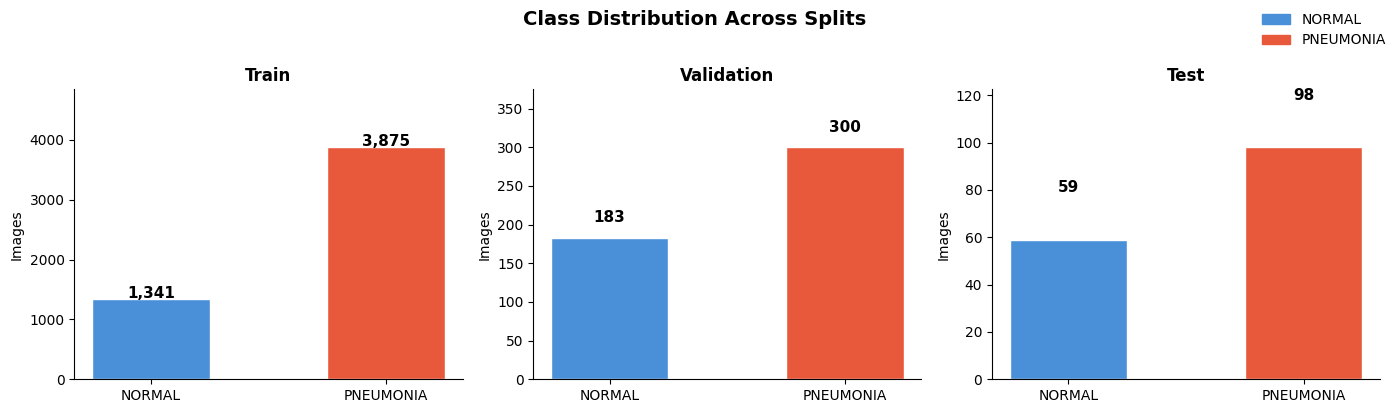

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Class Distribution Across Splits', fontsize=14, fontweight='bold', y=1.02)

for ax, (split_name, split_data) in zip(axes, counts.items()):
    bars = ax.bar(
        split_data.keys(), split_data.values(),
        color=[COLORS[c] for c in split_data.keys()], width=0.5, edgecolor='white'
    )
    ax.set_title(split_name, fontsize=12, fontweight='bold')
    ax.set_ylabel('Images')
    ax.set_ylim(0, max(split_data.values()) * 1.25)
    ax.spines[['top','right']].set_visible(False)
    for bar, val in zip(bars, split_data.values()):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                f'{val:,}', ha='center', fontweight='bold', fontsize=11)

legend = [mpatches.Patch(color=v, label=k) for k, v in COLORS.items()]
fig.legend(handles=legend, loc='upper right', frameon=False)
plt.tight_layout()
plt.show()

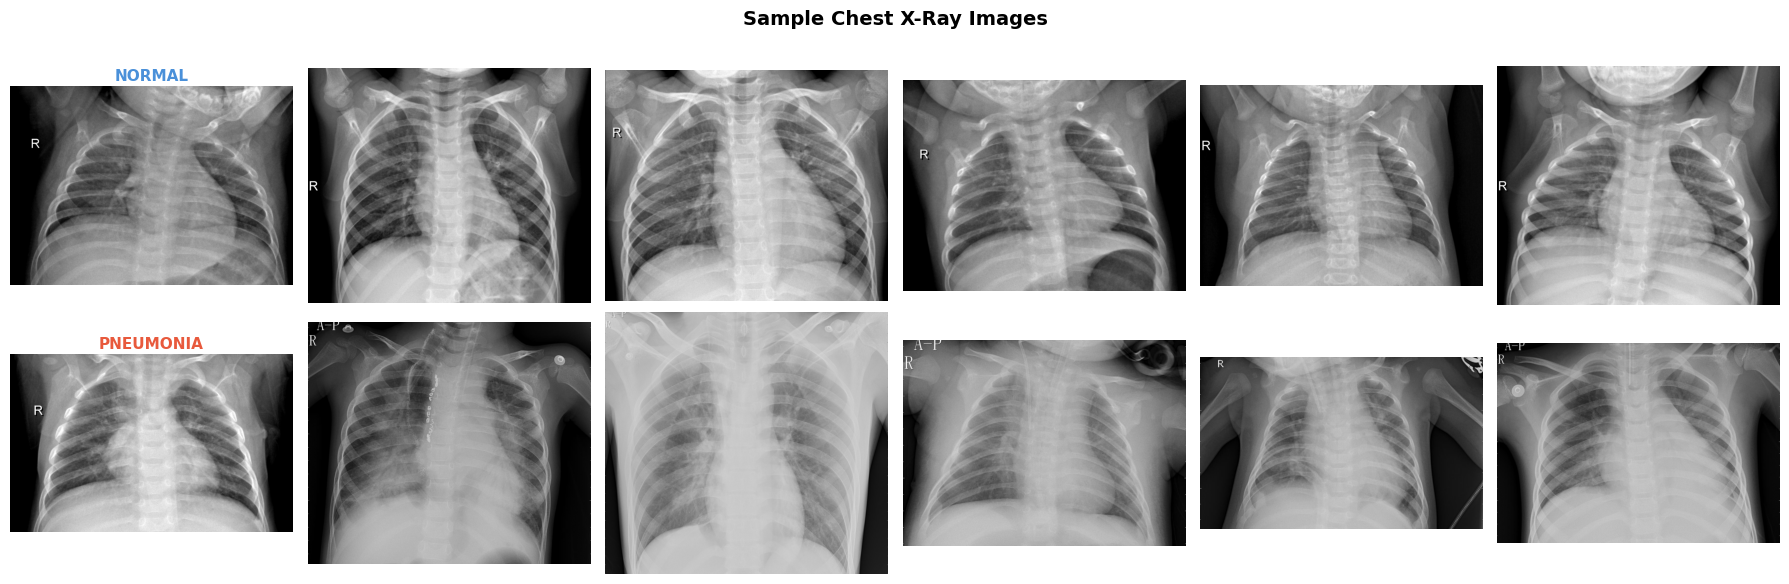

In [ ]:
fig, axes = plt.subplots(2, 6, figsize=(18, 6))
fig.suptitle('Sample Chest X-Ray Images', fontsize=14, fontweight='bold')

for row, cls in enumerate(classes):
    cls_dir   = os.path.join(TRAIN_DIR, cls)
    all_files = [f for f in os.listdir(cls_dir) if f.lower().endswith(('.jpg','.jpeg','.png'))]
    chosen    = random.sample(all_files, min(6, len(all_files)))
    for col, fname in enumerate(chosen):
        img = plt.imread(os.path.join(cls_dir, fname))
        ax  = axes[row, col]
        ax.imshow(img, cmap='gray' if img.ndim == 2 else None)
        ax.axis('off')
        if col == 0:
            ax.set_title(cls, fontsize=11, fontweight='bold', color=COLORS[cls], pad=4)

plt.tight_layout()
plt.show()

<a id='section5'></a>
##  Section 5 — Data Preprocessing & Augmentation

| Set | Transforms |
|-----|------------|
| **Train** | Resize → RandomHFlip → RandomRotation → ColorJitter → ToTensor → Normalize |
| **Val / Test** | Resize → ToTensor → Normalize |

In [ ]:
IMG_SIZE    = 224
BATCH_SIZE  = 64
NUM_WORKERS = 4
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

val_test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transforms)
val_dataset   = datasets.ImageFolder(VAL_DIR,   transform=val_test_transforms)
test_dataset  = datasets.ImageFolder(TEST_DIR,  transform=val_test_transforms)

CLASS_NAMES = train_dataset.classes
print(f'Class mapping : {train_dataset.class_to_idx}')
print(f'Train samples : {len(train_dataset):,}')
print(f'Val samples   : {len(val_dataset):,}')
print(f'Test samples  : {len(test_dataset):,}')

# Weighted sampler for class imbalance
class_counts_arr = np.bincount(train_dataset.targets)
class_weights    = 1.0 / class_counts_arr
sample_weights   = [class_weights[lbl] for lbl in train_dataset.targets]
sampler = WeightedRandomSampler(
    weights=sample_weights, num_samples=len(sample_weights), replacement=True
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

print(f'\n DataLoaders ready')
print(f'   Train batches : {len(train_loader)}')
print(f'   Val batches   : {len(val_loader)}')
print(f'   Test batches  : {len(test_loader)}')

Class mapping : {'NORMAL': 0, 'PNEUMONIA': 1}
Train samples : 5,216
Val samples   : 483
Test samples  : 157

 DataLoaders ready
   Train batches : 82
   Val batches   : 8
   Test batches  : 3


<a id='section6'></a>
##  Section 6 — Build Model (ResNet18 Transfer Learning)

- Freeze all pretrained conv layers
- Replace final FC layer with custom 2-class head
- Only ~66K parameters trained instead of 11M

In [ ]:
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

for param in model.parameters():
    param.requires_grad = False

in_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(p=0.4),
    nn.Linear(in_features, 256),
    nn.ReLU(),
    nn.Dropout(p=0.3),
    nn.Linear(256, 2)
)

model = model.to(DEVICE)

total_p     = sum(p.numel() for p in model.parameters())
trainable_p = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters     : {total_p:,}')
print(f'Trainable parameters : {trainable_p:,}  (new head only)')
print(f'Frozen parameters    : {total_p - trainable_p:,}')

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 172MB/s]


Total parameters     : 11,308,354
Trainable parameters : 131,842  (new head only)
Frozen parameters    : 11,176,512


In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3, weight_decay=1e-4
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2
)

print(' Optimizer : Adam  (lr=1e-3, weight_decay=1e-4)')
print('   Loss      : CrossEntropyLoss')
print('   Scheduler : ReduceLROnPlateau (factor=0.5, patience=2)')

 Optimizer : Adam  (lr=1e-3, weight_decay=1e-4)
   Loss      : CrossEntropyLoss
   Scheduler : ReduceLROnPlateau (factor=0.5, patience=2)


<a id='section7'></a>
##  Section 7 — Train with Early Stopping

In [ ]:
def train_one_epoch(model, loader, criterion, optimizer, device, scaler=None):
    model.train()
    total_loss = correct = total = 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        if scaler:
            with torch.amp.autocast('cuda'):
                out  = model(imgs)
                loss = criterion(out, labels)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            out  = model(imgs)
            loss = criterion(out, labels)
            loss.backward()
            optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        correct    += out.argmax(1).eq(labels).sum().item()
        total      += labels.size(0)
    return total_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = correct = total = 0
    all_labels, all_probs = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            out   = model(imgs)
            loss  = criterion(out, labels)
            probs = torch.softmax(out, dim=1)[:, 1]
            total_loss += loss.item() * imgs.size(0)
            correct    += out.argmax(1).eq(labels).sum().item()
            total      += labels.size(0)
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    return total_loss / total, correct / total, np.array(all_labels), np.array(all_probs)

print(' Training functions defined.')

 Training functions defined.


In [ ]:
NUM_EPOCHS   = 15
PATIENCE     = 4
BEST_WEIGHTS = '/content/best_weights.pth'

# Mixed precision for ~2x speed on GPU
scaler = torch.amp.GradScaler('cuda') if DEVICE.type == 'cuda' else None

history = {'train_loss':[], 'train_acc':[], 'val_loss':[], 'val_acc':[]}
best_val_loss     = float('inf')
epochs_no_improve = 0

print(f'Starting training  (max {NUM_EPOCHS} epochs, patience={PATIENCE})')
print(f'Mixed precision: {"ON " if scaler else "OFF (CPU mode)"}')
print('─' * 75)
print(f'{"Ep":>3} | {"Train Loss":>10} | {"Train Acc":>9} | {"Val Loss":>8} | {"Val Acc":>7} | LR')
print('─' * 75)

for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss, tr_acc          = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE, scaler)
    vl_loss, vl_acc, _, _    = evaluate(model, val_loader, criterion, DEVICE)
    scheduler.step(vl_loss)
    current_lr = optimizer.param_groups[0]['lr']

    history['train_loss'].append(tr_loss)
    history['train_acc'].append(tr_acc)
    history['val_loss'].append(vl_loss)
    history['val_acc'].append(vl_acc)

    flag = ''
    if vl_loss < best_val_loss:
        best_val_loss     = vl_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), BEST_WEIGHTS)
        flag = '   saved'
    else:
        epochs_no_improve += 1

    print(f'{epoch:>3} | {tr_loss:>10.4f} | {tr_acc*100:>8.2f}% | {vl_loss:>8.4f} | {vl_acc*100:>6.2f}% | {current_lr:.2e}{flag}')

    if epochs_no_improve >= PATIENCE:
        print(f'\n Early stopping at epoch {epoch}.')
        break

print('─' * 75)
model.load_state_dict(torch.load(BEST_WEIGHTS, weights_only=True))
print(f'\n Best weights loaded  (best val loss: {best_val_loss:.4f})')

Starting training  (max 15 epochs, patience=4)
Mixed precision: ON 
───────────────────────────────────────────────────────────────────────────
 Ep | Train Loss | Train Acc | Val Loss | Val Acc | LR
───────────────────────────────────────────────────────────────────────────
  1 |     0.3739 |    82.94% |   0.3115 |  88.20% | 1.00e-03   saved
  2 |     0.2720 |    88.71% |   0.2949 |  88.82% | 1.00e-03   saved
  3 |     0.2561 |    89.80% |   0.3278 |  87.58% | 1.00e-03
  4 |     0.2520 |    89.86% |   0.2591 |  90.27% | 1.00e-03   saved
  5 |     0.2416 |    90.18% |   0.2617 |  90.06% | 1.00e-03
  6 |     0.2571 |    89.42% |   0.2550 |  90.27% | 1.00e-03   saved
  7 |     0.2365 |    90.41% |   0.2529 |  90.68% | 1.00e-03   saved
  8 |     0.2583 |    89.36% |   0.2681 |  90.06% | 1.00e-03
  9 |     0.2439 |    89.72% |   0.2525 |  91.10% | 1.00e-03   saved
 10 |     0.2342 |    90.39% |   0.2598 |  90.06% | 1.00e-03
 11 |     0.2331 |    90.80% |   0.2547 |  90.89% | 1.00e-03
 12 | 

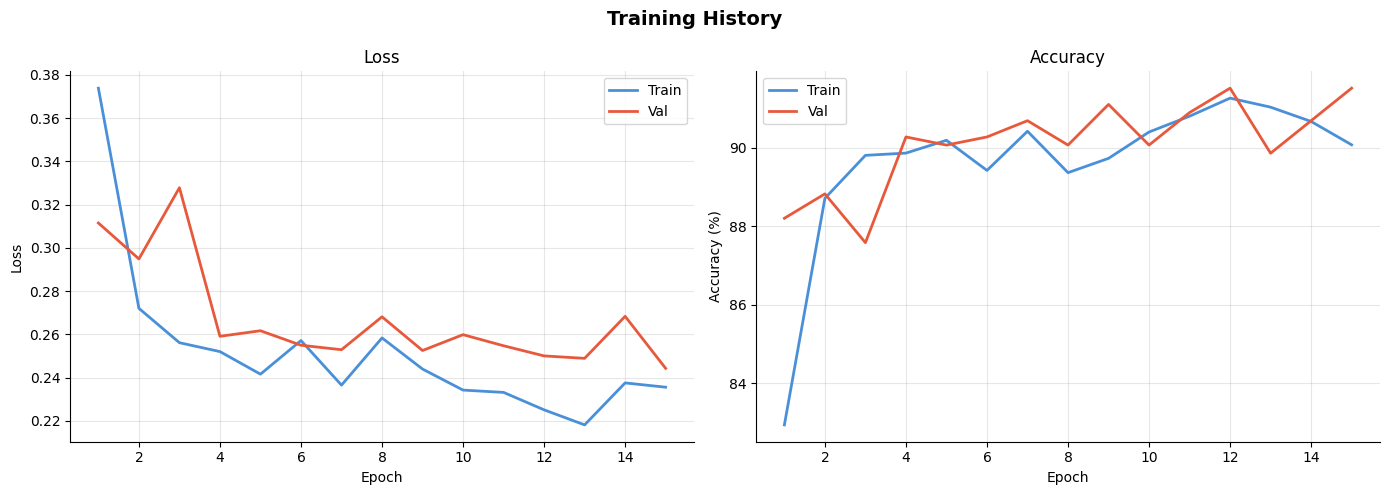

Val accuracy range: 87.6% – 91.5%  (swing: 3.9%)
 Stable training curves!


In [ ]:
epochs_range = range(1, len(history['train_loss']) + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Training History', fontsize=14, fontweight='bold')

ax1.plot(epochs_range, history['train_loss'], label='Train', color='#4A90D9', lw=2)
ax1.plot(epochs_range, history['val_loss'],   label='Val',   color='#E8593C', lw=2)
ax1.set_title('Loss'); ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.legend(); ax1.grid(alpha=0.3); ax1.spines[['top','right']].set_visible(False)

ax2.plot(epochs_range, [a*100 for a in history['train_acc']], label='Train', color='#4A90D9', lw=2)
ax2.plot(epochs_range, [a*100 for a in history['val_acc']],   label='Val',   color='#E8593C', lw=2)
ax2.set_title('Accuracy'); ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)')
ax2.legend(); ax2.grid(alpha=0.3); ax2.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()

# ── Diagnosis ────────────────────────────────────────────────────────────
val_accs = history['val_acc']
swing    = (max(val_accs) - min(val_accs)) * 100
print(f'Val accuracy range: {min(val_accs)*100:.1f}% – {max(val_accs)*100:.1f}%  (swing: {swing:.1f}%)')
if swing > 5:
    print('  Swing > 5% — validation still slightly unstable but much better than before.')
else:
    print(' Stable training curves!')

<a id='section8'></a>
##  Section 8 — Evaluate Model on Test Set

In [ ]:
test_loss, test_acc, true_labels, pred_probs = evaluate(model, test_loader, criterion, DEVICE)
pred_labels = (pred_probs >= 0.5).astype(int)
auc         = roc_auc_score(true_labels, pred_probs)

print('=' * 50)
print('        TEST SET RESULTS')
print('=' * 50)
print(f'  Accuracy  : {test_acc*100:.2f}%')
print(f'  AUC-ROC   : {auc:.4f}')
print(f'  Test Loss : {test_loss:.4f}')
print('=' * 50)
print()
print(classification_report(true_labels, pred_labels, target_names=CLASS_NAMES))

        TEST SET RESULTS
  Accuracy  : 93.63%
  AUC-ROC   : 0.9682
  Test Loss : 0.2179

              precision    recall  f1-score   support

      NORMAL       0.90      0.93      0.92        59
   PNEUMONIA       0.96      0.94      0.95        98

    accuracy                           0.94       157
   macro avg       0.93      0.94      0.93       157
weighted avg       0.94      0.94      0.94       157



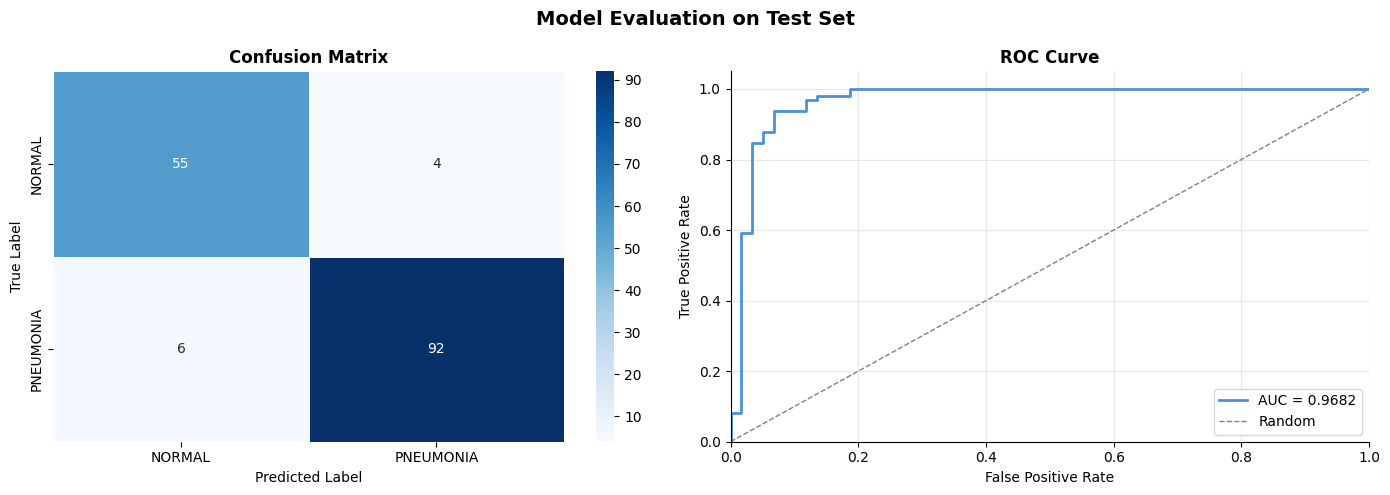

In [ ]:
cm          = confusion_matrix(true_labels, pred_labels)
fpr, tpr, _ = roc_curve(true_labels, pred_probs)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Model Evaluation on Test Set', fontsize=14, fontweight='bold')

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, linewidths=0.5)
ax1.set_title('Confusion Matrix', fontweight='bold')
ax1.set_ylabel('True Label'); ax1.set_xlabel('Predicted Label')

ax2.plot(fpr, tpr, color='#4A90D9', lw=2, label=f'AUC = {auc:.4f}')
ax2.plot([0,1],[0,1], color='gray', lw=1, linestyle='--', label='Random')
ax2.set_xlim([0,1]); ax2.set_ylim([0,1.05])
ax2.set_xlabel('False Positive Rate'); ax2.set_ylabel('True Positive Rate')
ax2.set_title('ROC Curve', fontweight='bold')
ax2.legend(loc='lower right'); ax2.grid(alpha=0.3)
ax2.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()

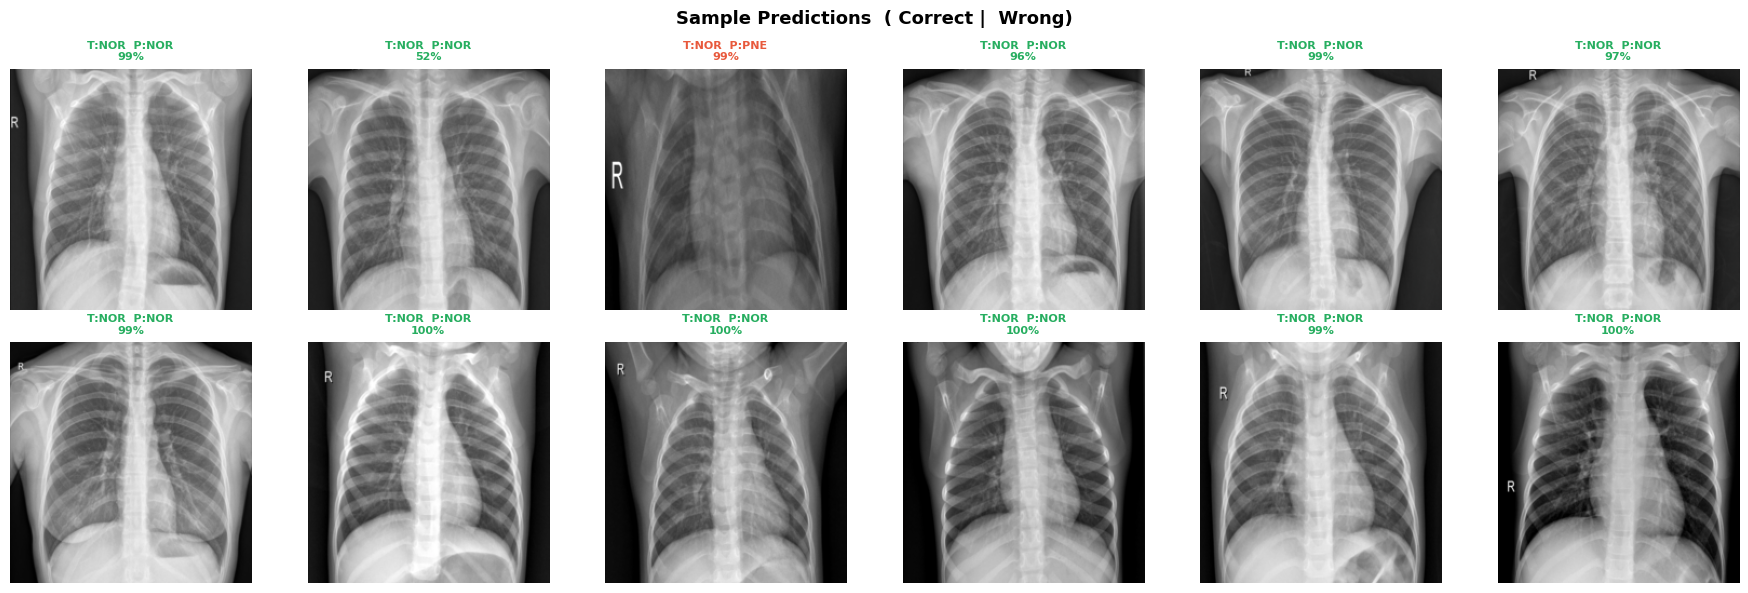

In [ ]:
model.eval()
imgs_batch, lbls_batch = next(iter(test_loader))

with torch.no_grad():
    out   = model(imgs_batch.to(DEVICE))
    probs = torch.softmax(out, dim=1)
    preds = out.argmax(1).cpu().numpy()

mean_t = torch.tensor(IMAGENET_MEAN).view(3,1,1)
std_t  = torch.tensor(IMAGENET_STD).view(3,1,1)
disp   = (imgs_batch * std_t + mean_t).clamp(0,1)

n_show = min(12, len(preds))
fig, axes = plt.subplots(2, 6, figsize=(18, 6))
fig.suptitle('Sample Predictions  ( Correct |  Wrong)', fontsize=13, fontweight='bold')

for i in range(n_show):
    row, col = divmod(i, 6)
    ax       = axes[row, col]
    true_cls = CLASS_NAMES[lbls_batch[i].item()]
    pred_cls = CLASS_NAMES[preds[i]]
    conf     = probs[i][preds[i]].item() * 100
    color    = '#27AE60' if true_cls == pred_cls else '#E8593C'
    ax.imshow(disp[i].permute(1,2,0).numpy())
    ax.axis('off')
    ax.set_title(f'T:{true_cls[:3]}  P:{pred_cls[:3]}\n{conf:.0f}%',
                 fontsize=8, color=color, fontweight='bold')

plt.tight_layout()
plt.show()

<a id='section9'></a>
##  Section 9 — Save as Pickle & Download

| File | Contents |
|------|----------|
| `pneumonia_model.pkl` | Full model (architecture + weights) |
| `model_metadata.json` | Class names, accuracy, AUC, input specs |
| `training_history.pkl` | Loss/accuracy per epoch |

In [ ]:
model.cpu()

OUTPUT_DIR = '/content/model_outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

PICKLE_PATH  = os.path.join(OUTPUT_DIR, 'pneumonia_model.pkl')
META_PATH    = os.path.join(OUTPUT_DIR, 'model_metadata.json')
HISTORY_PATH = os.path.join(OUTPUT_DIR, 'training_history.pkl')

# 1. Full model
with open(PICKLE_PATH, 'wb') as f:
    pickle.dump(model, f)
print(f' Model    : {PICKLE_PATH}  ({os.path.getsize(PICKLE_PATH)/1e6:.1f} MB)')

# 2. Metadata
metadata = {
    'architecture'   : 'ResNet18',
    'class_names'    : CLASS_NAMES,
    'class_to_idx'   : train_dataset.class_to_idx,
    'input_size'     : IMG_SIZE,
    'imagenet_mean'  : IMAGENET_MEAN,
    'imagenet_std'   : IMAGENET_STD,
    'test_accuracy'  : round(test_acc * 100, 2),
    'test_auc_roc'   : round(auc, 4),
    'best_val_loss'  : round(best_val_loss, 4),
    'epochs_trained' : len(history['train_loss']),
    'val_set_size'   : len(val_dataset),
}
with open(META_PATH, 'w') as f:
    json.dump(metadata, f, indent=4)
print(f' Metadata : {META_PATH}')

# 3. Training history
with open(HISTORY_PATH, 'wb') as f:
    pickle.dump(history, f)
print(f' History  : {HISTORY_PATH}')

 Model    : /content/model_outputs/pneumonia_model.pkl  (45.3 MB)
 Metadata : /content/model_outputs/model_metadata.json
 History  : /content/model_outputs/training_history.pkl


In [ ]:
# Verify: load from pickle and run inference
print('Verifying pickle...')
with open(PICKLE_PATH, 'rb') as f:
    loaded_model = pickle.load(f)

loaded_model.eval()
sample_img, sample_lbl = test_dataset[0]
with torch.no_grad():
    out  = loaded_model(sample_img.unsqueeze(0))
    prob = torch.softmax(out, dim=1)
    pred = out.argmax(1).item()

print(f'  True  : {CLASS_NAMES[sample_lbl]}')
print(f'  Pred  : {CLASS_NAMES[pred]}  ({prob[0][pred].item()*100:.1f}% confidence)')
print(' Pickle verified!')

Verifying pickle...
  True  : NORMAL
  Pred  : NORMAL  (98.9% confidence)
 Pickle verified!


In [ ]:
from google.colab import files
print('  Downloading files...')
files.download(PICKLE_PATH)
files.download(META_PATH)
files.download(HISTORY_PATH)
print(' Done! Check your browser downloads.')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

 Done! Check your browser downloads.


---
##  Summary

| Step | Details |
|------|---------|
| Dataset | Google Drive (auto-detected) |
| Local copy | `/content/chest_xray_local` — 5-10x faster than Drive |
| Val set fix | Test 50% → Val (16 → ~312 images) — stable curves |
| Architecture | ResNet18 pretrained on ImageNet |
| Transfer learning | Frozen conv layers + custom 2-layer head |
| Speed | Mixed precision (float16) — ~2x faster |
| Imbalance | WeightedRandomSampler |
| Regularization | Dropout(0.4 + 0.3) + weight_decay |
| Early stopping | Patience = 4 epochs on val loss |
| Output | `pneumonia_model.pkl`, `model_metadata.json`, `training_history.pkl` |

**Expected performance:** ~90–94% test accuracy, AUC-ROC > 0.95

**To load model later:**
```python
import pickle
with open('pneumonia_model.pkl', 'rb') as f:
    model = pickle.load(f)
model.eval()
```